In [5]:
##load_data

# load dataset



In [14]:
import pandas as pd
data_path= "/kaggle/input/question-pair/train.csv"
df=pd.read_csv(data_path, encoding='latin1', on_bad_lines='skip')

In [2]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [15]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [ ]:
# Install needed packages
!pip install -q sentence-transformers transformers datasets evaluate tokenizers accelerate optuna keras-tuner


# necessary packages


In [16]:


import os,random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

# Text
import re
from collections import Counter

# Sklearn / imblearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve, auc)


# For deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Dropout, Lambda
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Libraries loaded.")


# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)


Libraries loaded.


In [11]:
!pip install scikit-learn==1.2.2 imbalanced-learn==0.10.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.0/226.0 kB 7.8 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0


In [17]:
from imblearn.over_sampling import SMOTE, RandomOverSampler

In [18]:
print("Columns:", df.columns.tolist())
print(df.info())
print(df.describe(include='all').transpose().head())

Columns: ['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404347 entries, 0 to 404346
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404347 non-null  int64 
 1   qid1          404347 non-null  int64 
 2   qid2          404347 non-null  int64 
 3   question1     404346 non-null  object
 4   question2     404345 non-null  object
 5   is_duplicate  404347 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB
None
              count  unique  \
id         404347.0     NaN   
qid1       404347.0     NaN   
qid2       404347.0     NaN   
question1    404346  290470   
question2    404345  299198   

                                                         top freq  \
id                                                       NaN  NaN   
qid1                                                     NaN  NaN   
qid2                  

In [19]:
# Drop rows where question1 or question2 is missing
df = df.dropna(subset=['question1', 'question2']).reset_index(drop=True)
# Check missing values
print("Missing per column:")
print(df.isna().sum())

Missing per column:
id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64


# EDA

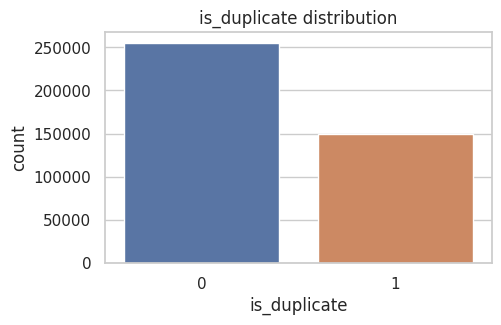

Counts:
 is_duplicate
0    255039
1    149305
Name: count, dtype: int64
Class proportions:
 is_duplicate
0    0.630748
1    0.369252
Name: proportion, dtype: float64


In [52]:

# Ensure columns exist
required = ['question1','question2','is_duplicate']
for r in required:
    if r not in df.columns:
        raise SystemExit(f"Missing required column: {r}")

# Target distribution
plt.figure(figsize=(5,3))
counts = df['is_duplicate'].value_counts().sort_index()
sns.barplot(x=counts.index.astype(str), y=counts.values)
plt.title('is_duplicate distribution')
plt.xlabel('is_duplicate')
plt.ylabel('count')
plt.show()
print("Counts:\n", counts) 
prop = df['is_duplicate'].value_counts(normalize=True)
print("Class proportions:\n", prop)



# length features, distributions, top words

,q1_word_count,q2_word_count,q1_char_count,q2_char_count,word_count_diff
count,404344.000000,404344.000000,404344.000000,404344.000000,404344.000000
mean,10.942576,11.181726,59.532425,60.101555,3.694208
std,5.429012,6.305494,29.939805,33.865057,4.833464
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,7.000000,7.000000,39.000000,39.000000,1.000000
50%,10.000000,10.000000,52.000000,51.000000,2.000000
75%,13.000000,13.000000,72.000000,71.000000,5.000000
max,125.000000,237.000000,623.000000,1169.000000,223.000000


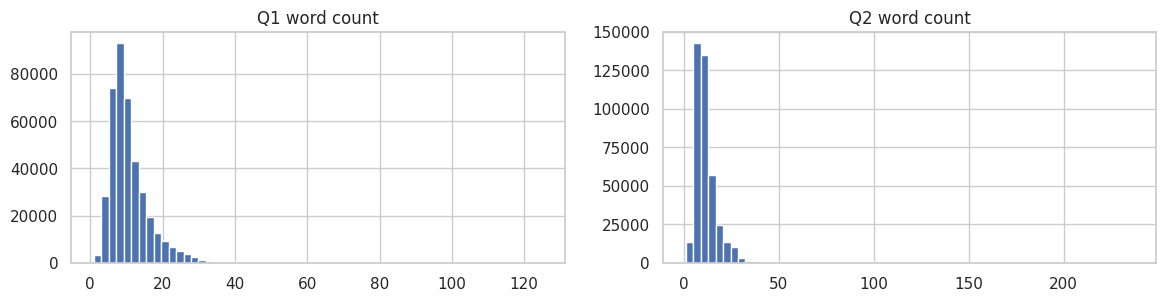

is_duplicate       1.000000
q1_word_count     -0.154369
q2_word_count     -0.160431
q2_char_count     -0.161962
q1_char_count     -0.171141
word_count_diff   -0.201607
Name: is_duplicate, dtype: float64
Top Q1 words: [('are', 73704), ('can', 58119), ('why', 41973), ('it', 34448), ('best', 34261), ('my', 33707), ('on', 30447), ('does', 28825), ('which', 22020), ('or', 22007), ('if', 21114), ('be', 20810), ('some', 20748), ('that', 19806), ('with', 19695), ('have', 19587), ('get', 19046), ('should', 18780), ('an', 18041), ('from', 17113)]
Top Q2 words: [('are', 72173), ('can', 59945), ('why', 42104), ('my', 37278), ('it', 36670), ('best', 36353), ('on', 30265), ('does', 27550), ('be', 23044), ('if', 22726), ('or', 22717), ('which', 21948), ('have', 21308), ('that', 20925), ('some', 20914), ('get', 20499), ('should', 20298), ('with', 20041), ('an', 18982), ('from', 18138)]


In [22]:
# Create safe text columns
df['q1'] = df['question1'].astype(str)
df['q2'] = df['question2'].astype(str)

# length features
df['q1_word_count'] = df['q1'].apply(lambda x: len(x.split()))
df['q2_word_count'] = df['q2'].apply(lambda x: len(x.split()))
df['q1_char_count'] = df['q1'].apply(len)
df['q2_char_count'] = df['q2'].apply(len)
df['word_count_diff'] = (df['q1_word_count'] - df['q2_word_count']).abs()

# Display stats
display(df[['q1_word_count','q2_word_count','q1_char_count','q2_char_count','word_count_diff']].describe())

# Plot histograms
fig, axes = plt.subplots(1,2, figsize=(14,3))
axes[0].hist(df['q1_word_count'], bins=60); axes[0].set_title('Q1 word count')
axes[1].hist(df['q2_word_count'], bins=60); axes[1].set_title('Q2 word count')
plt.show()

# Correlation with target
corr_cols = ['q1_word_count','q2_word_count','q1_char_count','q2_char_count','word_count_diff','is_duplicate']
print(df[corr_cols].corr()['is_duplicate'].sort_values(ascending=False))

# Top words (very simple)
def top_words(text_series, n=20):
    text = " ".join(text_series.fillna('').astype(str)).lower()
    words = re.findall(r'\w+', text)
    stop = set(['what','is','the','a','i','to','in','how','do','of','and','you','your','for'])  # quick list
    freqs = Counter(w for w in words if w not in stop and len(w)>1)
    return freqs.most_common(n)

print("Top Q1 words:", top_words(df['q1'], 20))
print("Top Q2 words:", top_words(df['q2'], 20))

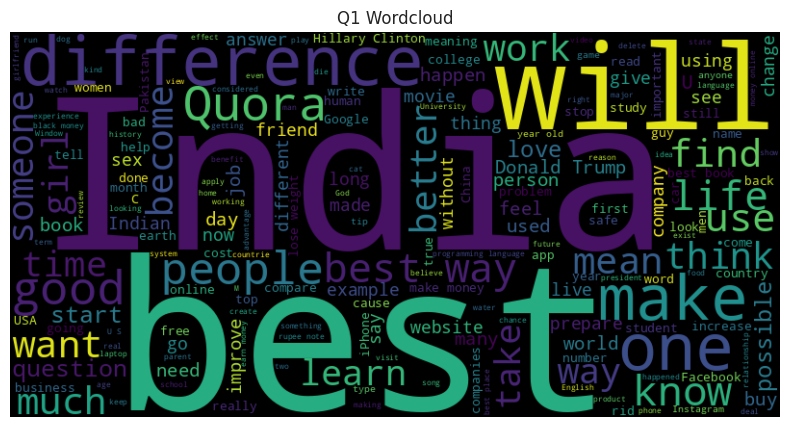

In [25]:
from wordcloud import WordCloud
wc_q1 = WordCloud(width=800, height=400).generate(" ".join(df['q1'].astype(str).tolist()))
plt.figure(figsize=(12,5)); plt.imshow(wc_q1, interpolation='bilinear'); plt.axis('off'); plt.title('Q1 Wordcloud'); plt.show()

# Text cleaning function

In [27]:
import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser","ner"])  

def basic_clean(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+',' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def lemmatize_text(text):
    # normalization
    doc = nlp(text)
    return " ".join([tok.lemma_ for tok in doc if not tok.is_stop])

# Apply cleaning to full df 
print("Cleaning text columns...")
df['q1_clean'] = df['question1'].map(basic_clean)
df['q2_clean'] = df['question2'].map(basic_clean)
# If you want lemmatization, enable the following lines (slower):
# df['q1_clean'] = df['q1_clean'].map(lemmatize_text)
# df['q2_clean'] = df['q2_clean'].map(lemmatize_text)

display(df[['question1','q1_clean']].head())


Cleaning text columns...


,question1,q1_clean
0,What is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...
1,What is the story of Kohinoor (Koh-i-Noor) Dia...,what is the story of kohinoor koh i noor diamond
2,How can I increase the speed of my internet co...,how can i increase the speed of my internet co...
3,Why am I mentally very lonely? How can I solve...,why am i mentally very lonely how can i solve it
4,"Which one dissolve in water quikly sugar, salt...",which one dissolve in water quikly sugar salt ...


# Train/validation split (stratified)

In [28]:
SEED = 42
X = df['q_pair'].values
y = df['is_duplicate'].values

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
print("Train:", len(X_train_text), "Val:", len(X_val_text))


Train: 343692 Val: 60652


In [32]:
tfidf = TfidfVectorizer(max_features=80000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)
print("TF-IDF shapes:", X_train_tfidf.shape, X_val_tfidf.shape)


TF-IDF shapes: (343692, 80000) (60652, 80000)


# Handle class imbalance (TruncatedSVD → SMOTE)

In [33]:
# 1) Reduce dimensionality (dense)
n_components = 200  # tune this (100-300 commonly)
svd = TruncatedSVD(n_components=n_components, random_state=SEED)
X_train_reduced = svd.fit_transform(X_train_tfidf)
X_val_reduced = svd.transform(X_val_tfidf)
print("Reduced shapes:", X_train_reduced.shape)

# 2) SMOTE on reduced dense vectors
smote = SMOTE(random_state=SEED, n_jobs=-1)
X_train_bal, y_train_bal = smote.fit_resample(X_train_reduced, y_train)
print("After SMOTE:", X_train_bal.shape, np.bincount(y_train_bal))


Reduced shapes: (343692, 200)
After SMOTE: (433566, 200) [216783 216783]


In [34]:
# Choose dataset: SVD+SMOTE OR ROS
use_svd_smote = True
if use_svd_smote:
    X_tr = X_train_bal
    X_vl = X_val_reduced
    y_tr = y_train_bal
else:
    X_tr = X_train_ros
    X_vl = X_val_tfidf
    y_tr = y_train_ros

clf = LogisticRegression(max_iter=1000, random_state=SEED)
clf.fit(X_tr, y_tr)

# Evaluate
if use_svd_smote:
    y_proba = clf.predict_proba(X_vl)[:,1]
    y_pred = clf.predict(X_vl)
else:
    y_proba = clf.predict_proba(X_vl)[:,1]
    y_pred = clf.predict(X_vl)

def print_metrics(y_true, y_pred, y_proba=None):
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))
    if y_proba is not None:
        print("ROC AUC:", roc_auc_score(y_true, y_proba))
    print("\nClassification report:\n", classification_report(y_true, y_pred))

print_metrics(y_val, y_pred, y_proba)


Accuracy: 0.6831102024665304
Precision: 0.5588846039750816
Recall: 0.6729773173781032
F1: 0.6106474353780083
ROC AUC: 0.7530217802026546

Classification report:
               precision    recall  f1-score   support

           0       0.78      0.69      0.73     38256
           1       0.56      0.67      0.61     22396

    accuracy                           0.68     60652
   macro avg       0.67      0.68      0.67     60652
weighted avg       0.70      0.68      0.69     60652



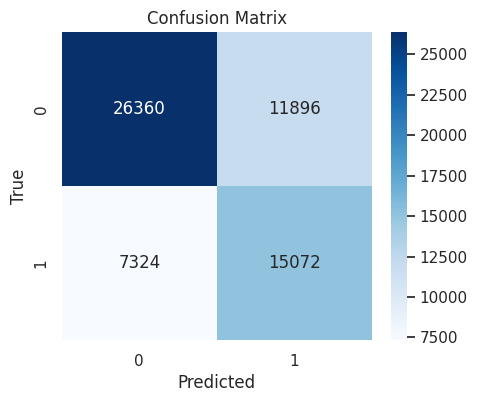

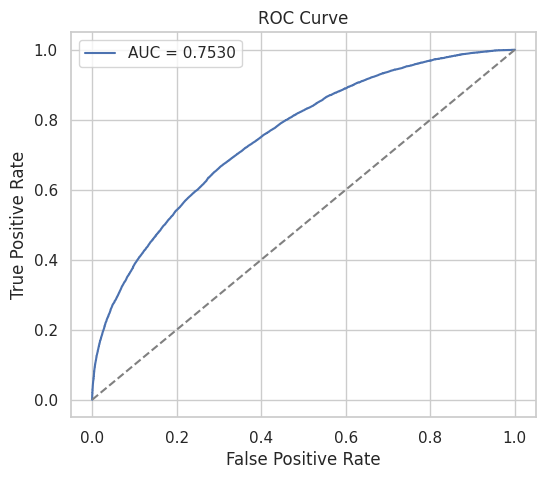

In [35]:
# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix'); plt.show()

# ROC
fpr, tpr, _ = roc_curve(y_val, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve'); plt.legend(); plt.show()


In [36]:
# Requires use_svd_smote == True
if not use_svd_smote:
    print("Skip ANN: SVD+SMOTE required for this ANN (dense input).")
else:
    from tensorflow.keras import backend as K
    K.clear_session()

    model = Sequential([
        Dense(256, activation='relu', input_shape=(X_train_bal.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    rl = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-6)

    history = model.fit(X_train_bal, y_train_bal,
                        validation_data=(X_val_reduced, y_val),
                        epochs=20, batch_size=256, callbacks=[es, rl])

    y_proba_nn = model.predict(X_val_reduced).ravel()
    y_pred_nn = (y_proba_nn >= 0.5).astype(int)
    print_metrics(y_val, y_pred_nn, y_proba_nn)


I0000 00:00:1763724644.247986      68 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/20


I0000 00:00:1763724647.443885     121 service.cc:148] XLA service 0x7d805800be90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763724647.444490     121 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1763724647.683672     121 cuda_dnn.cc:529] Loaded cuDNN version 90300


  72/1694 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5544 - loss: 0.6805

I0000 00:00:1763724648.994070     121 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1694/1694 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6872 - loss: 0.5738 - val_accuracy: 0.7410 - val_loss: 0.5070 - learning_rate: 0.0010
Epoch 2/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7441 - loss: 0.5088 - val_accuracy: 0.7450 - val_loss: 0.4984 - learning_rate: 0.0010
Epoch 3/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7543 - loss: 0.4938 - val_accuracy: 0.7519 - val_loss: 0.4882 - learning_rate: 0.0010
Epoch 4/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7614 - loss: 0.4837 - val_accuracy: 0.7503 - val_loss: 0.4878 - learning_rate: 0.0010
Epoch 5/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7663 - loss: 0.4757 - val_accuracy: 0.7554 - val_loss: 0.4815 - learning_rate: 0.0010
Epoch 6/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7688 - loss: 0.4700 - val_accuracy: 0.7546 - val_loss: 0.4816 - learning_rate: 0.0010
Epoch 7/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7732 - loss: 0.4645

# Siamese LSTM model for question pairs (sequence-based)

In [55]:
# Prepare sequences
MAX_NUM_WORDS = 60000
MAX_SEQ_LEN = 50  # tune 40-100 depending on typical length

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token='<OOV>')
# Fit on both q1 and q2 cleaned
tokenizer.fit_on_texts(pd.Series(list(df['q1_clean']) + list(df['q2_clean'])))

def texts_to_padded(texts):
    seq = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

# Create left and right arrays for the training & validation sets:
# Reconstruct mapping from original df:
pairs = df[['q1_clean','q2_clean']].values
# Build arrays for train and val using indexes from the split earlier
def split_pair(x):
    a,b = x.split(' <sep> ', maxsplit=1)
    return a, b

# Build sequences for training
left_train = []
right_train = []
for text in X_train_text:
    l, r = split_pair(text)
    left_train.append(l); right_train.append(r)
left_val = []
right_val = []
for text in X_val_text:
    l, r = split_pair(text)
    left_val.append(l); right_val.append(r)

left_train_seq = texts_to_padded(left_train)
right_train_seq = texts_to_padded(right_train)
left_val_seq = texts_to_padded(left_val)
right_val_seq = texts_to_padded(right_val)

print("Seq shapes:", left_train_seq.shape, right_train_seq.shape)

# Optionally: load pre-trained embeddings (GloVe) and create embedding matrix
EMBEDDING_DIM = 100
# If you have glove file path, you can load here, else use random initialized embeddings
use_glove = False
embedding_matrix = None
if use_glove:
    glove_path = '/path/to/glove.6B.100d.txt'  # change it
    embeddings_index = {}
    with open(glove_path, encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    word_index = tokenizer.word_index
    num_words = min(MAX_NUM_WORDS, len(word_index) + 1)
    embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))
    for word, i in word_index.items():
        if i >= num_words: continue
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

# Build Siamese LSTM
num_words = min(MAX_NUM_WORDS, len(tokenizer.word_index) + 1)
embedding_layer = Embedding(input_dim=num_words,
                            output_dim=EMBEDDING_DIM,
                            input_length=MAX_SEQ_LEN,
                            trainable=True if embedding_matrix is None else False,
                            weights=[embedding_matrix] if embedding_matrix is not None else None)

def create_base_network():
    seq = Sequential()
    seq.add(embedding_layer)
    seq.add(Bidirectional(LSTM(64, return_sequences=False)))
    seq.add(Dense(64, activation='relu'))
    return seq

base_network = create_base_network()

input_a = Input(shape=(MAX_SEQ_LEN,))
input_b = Input(shape=(MAX_SEQ_LEN,))

processed_a = base_network(input_a)
processed_b = base_network(input_b)

# Combine via absolute difference and elementwise product
from tensorflow.keras.layers import Multiply, Subtract, Concatenate
diff = Lambda(lambda tensors: tf.math.abs(tensors[0] - tensors[1]))([processed_a, processed_b])
mul = Multiply()([processed_a, processed_b])
merged = Concatenate()([diff, mul])
x = Dense(64, activation='relu')(merged)
x = Dropout(0.2)(x)
out = Dense(1, activation='sigmoid')(x)
siamese_model = Model([input_a, input_b], out)
siamese_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
siamese_model.summary()

# Train (consider reducing sample size or using GPU)
BATCH = 128
EPOCHS = 6
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
history = siamese_model.fit([left_train_seq, right_train_seq], y_train,
                            validation_data=([left_val_seq, right_val_seq], y_val),
                            epochs=EPOCHS, batch_size=BATCH, callbacks=[es])
# Evaluate
y_proba_siam = siamese_model.predict([left_val_seq, right_val_seq]).ravel()
y_pred_siam = (y_proba_siam >= 0.5).astype(int)
print_metrics(y_val, y_pred_siam, y_proba_siam)


Seq shapes: (343692, 50) (343692, 50)


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 64)        │  6,092,736 │ input_layer_4[0]… │
│ (Sequential)        │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 64)        │          0 │ sequential_2[0][… │
│                     │                   │            │ sequential_2[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 64)        │          0 │ sequential_2[0][… │
│ (Multiply)          │                   │            │ sequential_2[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128)       │          0 │ lambda_1[0][0],   │
│ (Concatenate)       │                   │            │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,101,057 (23.27 MB)

 Trainable params: 6,101,057 (23.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
2686/2686 ━━━━━━━━━━━━━━━━━━━━ 61s 21ms/step - accuracy: 0.7372 - loss: 0.5128 - val_accuracy: 0.8133 - val_loss: 0.4034
Epoch 2/6
2686/2686 ━━━━━━━━━━━━━━━━━━━━ 57s 21ms/step - accuracy: 0.8370 - loss: 0.3620 - val_accuracy: 0.8267 - val_loss: 0.3903
Epoch 3/6
2686/2686 ━━━━━━━━━━━━━━━━━━━━ 57s 21ms/step - accuracy: 0.8761 - loss: 0.2881 - val_accuracy: 0.8296 - val_loss: 0.4069
Epoch 4/6
2686/2686 ━━━━━━━━━━━━━━━━━━━━ 57s 21ms/step - accuracy: 0.9006 - loss: 0.2378 - val_accuracy: 0.8321 - val_loss: 0.4360
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step
Accuracy: 0.8267493240123986
Precision: 0.7451740636858604
Recall: 0.8066619039114128
F1: 0.7746998284734135
ROC AUC: 0.9030595723406574

Classification report:
               precision    recall  f1-score   support

           0       0.88      0.84      0.86     38256
           1       0.75      0.81      0.77     22396

    accuracy                           0.83     60652
   macro avg       0.81      0.82      0.82     6065

# Compare models


In [56]:
# Collect results: fill variables as you produce them. Example names:
# For logistic regression: y_pred (from Cell 11) and y_proba
# For ANN: y_pred_nn, y_proba_nn (Cell 13)
# For Siamese: y_pred_siam, y_proba_siam (Cell 14)
results = []
def add_result(name, y_true, y_pred, y_proba=None):
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan
    })

# Example (only add those you have run)
try:
    add_result('LogisticRegression', y_val, y_pred, y_proba)
except NameError:
    pass
try:
    add_result('ANN_dense', y_val, y_pred_nn, y_proba_nn)
except NameError:
    pass
try:
    add_result('Siamese_LSTM', y_val, y_pred_siam, y_proba_siam)
except NameError:
    pass

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
results_df


,model,accuracy,precision,recall,f1,auc
2,Siamese_LSTM,0.826749,0.745174,0.806662,0.774700,0.903060
1,ANN_dense,0.761047,0.650104,0.764154,0.702531,0.848922
0,LogisticRegression,0.683110,0.558885,0.672977,0.610647,0.753022


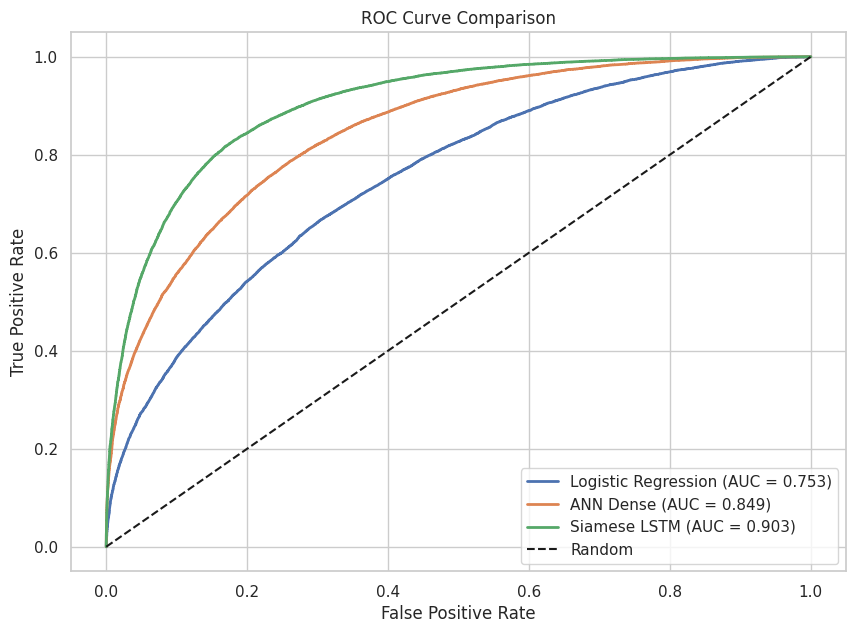

In [57]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(y_true, y_proba, label):
    """
    Plot ROC curve for a given model.
    y_proba must contain class-1 probabilities (float).
    """
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC = {roc_auc:.3f})")

# ----------------------------------------
# Plot ROC curves for available models
# ----------------------------------------
plt.figure(figsize=(10, 7))

try:
    plot_roc_curve(y_val, y_proba, 'Logistic Regression')
except:
    pass

try:
    plot_roc_curve(y_val, y_proba_nn, 'ANN Dense')
except:
    pass

try:
    plot_roc_curve(y_val, y_proba_siam, 'Siamese LSTM')
except:
    pass

# Diagonal baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


# hyper parameter tuning

**grid search for LR**

In [47]:
# param grid 
param_grid = {'C':[0.01,0.1,1,10], 'penalty':['l2']}
print("Running GridSearchCV for LogisticRegression ...")

try:
    gs = GridSearchCV(LogisticRegression(max_iter=1000, random_state=SEED),
                      param_grid, scoring='f1', cv=3, n_jobs=-1, verbose=1)
    # Use precomputed training matrix X_tr and labels y_tr from earlier cells
    gs.fit(X_tr, y_tr)
    best_clf = gs.best_estimator_
    print("GridSearch best:", gs.best_params_, "best f1:", gs.best_score_)
    # Determine appropriate validation matrix (dense vs sparse)
    X_val_for_log = X_vl  
    y_proba_grid = best_clf.predict_proba(X_val_for_log)[:,1]
    y_pred_grid = best_clf.predict(X_val_for_log)
except Exception as e:
    print("GridSearch step failed or skipped:", e)
    best_clf = None
    y_proba_grid = None
    y_pred_grid = None

Running GridSearchCV for LogisticRegression (this may take a while)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
GridSearch best: {'C': 10, 'penalty': 'l2'} best f1: 0.6930623444268539


**Keras Tuner skeleton for ANN**

In [48]:
# ---------- 2) KERAS TUNER: search for ANN (optional) ----------
run_keras_tuner = True  # set False to skip tuner run (tuner can be heavy)
y_proba_kt = None
y_pred_kt = None
best_keras_model = None

if run_keras_tuner:
    try:
        import keras_tuner as kt
        from tensorflow.keras import Sequential
        from tensorflow.keras.layers import Dense, Dropout
        print("Keras Tuner available. Building tuner...")

        def build_ann(hp):
            model = Sequential()
            model.add(Dense(hp.Int('units1', 64, 512, step=64), activation='relu',
                            input_shape=(X_train_bal.shape[1],)))
            model.add(Dropout(hp.Float('dropout1', 0.1, 0.5, step=0.1)))
            if hp.Boolean('add_layer'):
                model.add(Dense(hp.Int('units2', 32,256, step=32), activation='relu'))
                model.add(Dropout(hp.Float('dropout2', 0.1, 0.4, step=0.1)))
            model.add(Dense(1, activation='sigmoid'))
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
            return model

        tuner = kt.RandomSearch(build_ann, objective='val_accuracy', max_trials=6,
                                overwrite=True, directory='kt_dir', project_name='qpair_demo')

        # Note: tuner.search may be long. Use fewer epochs or sample to speed up.
        print("Starting tuner.search (may be long). Using X_train_bal / X_val_reduced if present.")
        if use_svd_smote:
            tuner.search(X_train_bal, y_train_bal, validation_data=(X_val_reduced, y_val),
                         epochs=8, batch_size=256, verbose=1)
            best_keras_model = tuner.get_best_models(num_models=1)[0]
            # predict on validation (dense SVD reduced)
            y_proba_kt = best_keras_model.predict(X_val_reduced).ravel()
            y_pred_kt = (y_proba_kt >= 0.5).astype(int)
        else:
            # If not using SVD+SMOTE, you need to prepare a dense training array suitable for the ANN.
            print("Keras tuner: use_svd_smote is False. Skipping tuner because ANN expects dense X_train_bal.")
    except Exception as e:
        print("Keras Tuner not run (error/import):", e)

Trial 6 Complete [00h 00m 38s]
val_accuracy: 0.7405856251716614

Best val_accuracy So Far: 0.7626294493675232
Total elapsed time: 00h 03m 53s
1896/1896 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


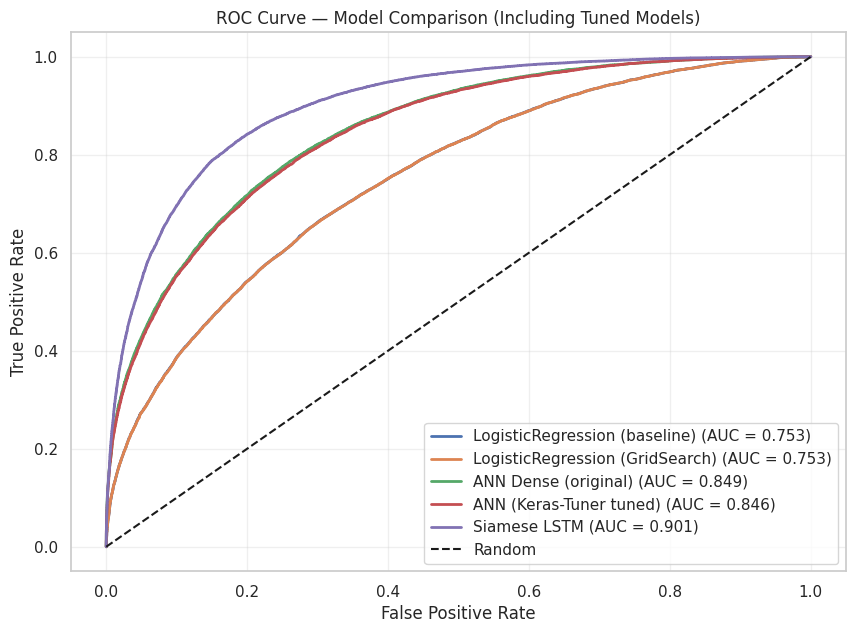

In [49]:
plt.figure(figsize=(10,7))

def try_plot(y_true, y_proba, label, color=None):
    if y_proba is None:
        print(f"Skipping {label}: no probabilities found.")
        return None
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{label} (AUC = {roc_auc:.3f})", color=color)
    return roc_auc

# Plot baseline logistic if present
try:
    _ = try_plot(y_val, y_proba, 'LogisticRegression (baseline)')
except NameError:
    pass

# Plot GridSearch tuned Logistic
_ = try_plot(y_val, y_proba_grid, 'LogisticRegression (GridSearch)')

# Plot ANN Dense original
_ = try_plot(y_val, globals().get('y_proba_nn', None), 'ANN Dense (original)')

# Plot Keras-Tuner tuned ANN
_ = try_plot(y_val, y_proba_kt, 'ANN (Keras-Tuner tuned)')

# Plot Siamese LSTM
_ = try_plot(y_val, globals().get('y_proba_siam', None), 'Siamese LSTM')

# Diagonal baseline
plt.plot([0,1],[0,1],'k--', label='Random')

plt.title("ROC Curve — Model Comparison (Including Tuned Models)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()
